# CKG Reasoner v2 — D_Influenza_4569

Organized Colab workflow for the manuscript experiments. The diagnostic reasoner is fitted without outcome labels; ground truth is used only after partitioning for retrospective evaluation.

## 0. Reproducibility configuration

In [1]:
# Manuscript configuration
DISEASE = 'Influenza'
TARGET = 'Flu_final_posneg'
BASELINE_K = 2
RANDOM_STATE = 42
K_RANGE = range(2, 11)
CLUSTER_VARIABLES = ["P_evidence", "r", "c", "Confidence_Score"]
BOOTSTRAP_N = 1000
WITHHOLD_FRACTIONS = [0.10, 0.25, 0.50]
SEEDS = list(range(20))

print("Disease:", DISEASE)
print("Target:", TARGET)
print("Baseline K:", BASELINE_K)
print("Baseline clustering variables:", CLUSTER_VARIABLES)

Disease: Influenza
Target: Flu_final_posneg
Baseline K: 2
Baseline clustering variables: ['P_evidence', 'r', 'c', 'Confidence_Score']


## 1. Colab / package setup

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Mounted at /content/drive


In [3]:
import sys
import os
import importlib

# ============================================================
# CKG REASONER — COLAB SOURCE SETUP + VALIDATION
# ============================================================

PACKAGE_PATH = "/content/drive/MyDrive/CKG/ckg_reasoner_package_v2"
SRC_PATH = os.path.join(PACKAGE_PATH, "src")
CKG_PATH = os.path.join(SRC_PATH, "ckg_reasoner")
DATA_PATH = os.path.join(CKG_PATH, "data")

print("=" * 70)
print("CKG REASONER — COLAB SOURCE SETUP")
print("=" * 70)

print("PACKAGE_PATH :", PACKAGE_PATH)
print("SRC_PATH     :", SRC_PATH)
print("CKG_PATH     :", CKG_PATH)

# ------------------------------------------------------------
# 1. Validate package structure
# ------------------------------------------------------------

required_directories = {
    "Package directory": PACKAGE_PATH,
    "Source directory": SRC_PATH,
    "CKG package directory": CKG_PATH,
}

for label, path in required_directories.items():
    exists = os.path.isdir(path)
    print(f"{label:<24}: {'OK' if exists else 'MISSING'}")

    if not exists:
        raise FileNotFoundError(
            f"{label} not found:\n{path}"
        )


required_files = [
    "__init__.py",
    "model.py",
    "reasoning.py",
    "knowledge.py",
]

missing_files = [
    filename
    for filename in required_files
    if not os.path.isfile(os.path.join(CKG_PATH, filename))
]

if missing_files:
    raise FileNotFoundError(
        "Required CKG package files are missing:\n"
        + "\n".join(f"  - {name}" for name in missing_files)
    )

print("\nRequired core package files: OK")


# ------------------------------------------------------------
# 2. Remove previously added CKG package paths
# ------------------------------------------------------------

old_paths = [
    p for p in sys.path
    if "ckg_reasoner_package" in str(p)
]

if old_paths:
    print("\nRemoving previous CKG source paths:")
    for p in old_paths:
        print("  ", p)

sys.path = [
    p for p in sys.path
    if "ckg_reasoner_package" not in str(p)
]


# ------------------------------------------------------------
# 3. Force the selected source directory to highest priority
# ------------------------------------------------------------

sys.path.insert(0, SRC_PATH)

print("\nActive source path:")
print(" ", sys.path[0])


# ------------------------------------------------------------
# 4. Remove stale imported CKG modules
# ------------------------------------------------------------

removed_modules = []

for name in list(sys.modules):
    if name == "ckg_reasoner" or name.startswith("ckg_reasoner."):
        removed_modules.append(name)
        del sys.modules[name]

if removed_modules:
    print("\nRemoved cached CKG modules:")
    for name in sorted(removed_modules):
        print("  ", name)
else:
    print("\nNo cached CKG modules found.")

importlib.invalidate_caches()


# ------------------------------------------------------------
# 5. Display package contents before import
# ------------------------------------------------------------

print("\n=== PACKAGE CONTENTS ===")

package_files = sorted(os.listdir(CKG_PATH))

for filename in package_files[:30]:
    print("  ", filename)

if len(package_files) > 30:
    print(f"  ... and {len(package_files) - 30} more")


# ------------------------------------------------------------
# 6. Import CKG Reasoner
# ------------------------------------------------------------

import ckg_reasoner
from ckg_reasoner import CKGModel


# ------------------------------------------------------------
# 7. Verify imported package
# ------------------------------------------------------------

print("\n=== IMPORT CHECK ===")

print("Imported from:")
print(" ", ckg_reasoner.__file__)

print("\nPackage path:")
for p in ckg_reasoner.__path__:
    print(" ", p)

CKG_VERSION = getattr(
    ckg_reasoner,
    "__version__",
    "NO VERSION"
)

print("\nVersion:", CKG_VERSION)
print(
    "CKGModel available:",
    hasattr(ckg_reasoner, "CKGModel")
)
print("CKGModel:", CKGModel)


# ------------------------------------------------------------
# 8. Safety check:
#    ensure Colab did not import another installed CKG package
# ------------------------------------------------------------

imported_file = os.path.realpath(ckg_reasoner.__file__)
expected_root = os.path.realpath(SRC_PATH)

try:
    common_root = os.path.commonpath(
        [imported_file, expected_root]
    )
except ValueError:
    common_root = ""

if common_root != expected_root:
    raise RuntimeError(
        "\nWRONG CKG PACKAGE IMPORTED!\n\n"
        f"Expected package under:\n{expected_root}\n\n"
        f"But imported:\n{imported_file}"
    )

print("\nSource-path verification: PASSED")


# ------------------------------------------------------------
# 9. Check important modules
# ------------------------------------------------------------

important_modules = [
    "condition_logic.py",
    "units.py",
    "function_policy.py",
    "functions.py",
    "clinical_transformer.py",
    "mapping.py",
    "retrieval.py",
    "reporting.py",
]

print("\n=== MODULE CHECK ===")

missing_modules = []

for filename in important_modules:
    path = os.path.join(CKG_PATH, filename)
    exists = os.path.isfile(path)

    print(
        f"{filename:<30}"
        f"{'OK' if exists else 'MISSING'}"
    )

    if not exists:
        missing_modules.append(filename)


# ------------------------------------------------------------
# 10. Check bundled knowledge/data files
# ------------------------------------------------------------

print("\n=== DATA / KNOWLEDGE CHECK ===")
print("Data directory:", DATA_PATH)
print(
    "Data directory exists:",
    os.path.isdir(DATA_PATH)
)

yaml_files = []

if os.path.isdir(DATA_PATH):

    for root, dirs, files in os.walk(DATA_PATH):

        for filename in files:

            if filename.lower().endswith(
                (".yaml", ".yml")
            ):
                yaml_files.append(
                    os.path.join(root, filename)
                )

    yaml_files = sorted(yaml_files)

    print("YAML/YML files found:", len(yaml_files))

    for path in yaml_files:
        print(
            "  ",
            os.path.relpath(path, CKG_PATH)
        )

else:
    print("WARNING: bundled data directory not found.")


# ------------------------------------------------------------
# 11. Final diagnostic summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CKG REASONER SETUP COMPLETED")
print("=" * 70)

print("Source       :", SRC_PATH)
print("Imported from:", ckg_reasoner.__file__)
print("Version      :", CKG_VERSION)
print("CKGModel     : READY")

print(
    "Core files   :",
    "OK" if not missing_files else "MISSING"
)

print(
    "Extra modules:",
    "OK" if not missing_modules
    else f"{len(missing_modules)} MISSING"
)

print(
    "Knowledge YAML:",
    len(yaml_files)
)

print("=" * 70)

CKG REASONER — COLAB SOURCE SETUP
PACKAGE_PATH : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2
SRC_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src
CKG_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner
Package directory       : OK
Source directory        : OK
CKG package directory   : OK

Required core package files: OK

Active source path:
  /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src

No cached CKG modules found.

=== PACKAGE CONTENTS ===
   __init__.py
   __pycache__
   clinical_transformer.py
   condition_logic.py
   confidence.py
   config.py
   data
   evaluation.py
   explanation.py
   function_policy.py
   functions.py
   gaussian.py
   graphview.py
   hard_assignment.py
   kmeans.py
   knowledge.py
   legacy_activation.py
   mahalanobis.py
   manual_audit.py
   mapping.py
   model.py
   reasoning.py
   reporting.py
   retrieval.py
   separation.py
   uncertainty.py
   units.py
   visualization.py

=== IMPORT CHECK =

In [4]:
from ckg_reasoner import CKGModel, __version__

model = CKGModel()

print("Version:", __version__)
print(model.kb.audit())

Version: 2
{'knowledge_base_path': '/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner/data/diseases', 'disease_graph_count': 3, 'diseases': ['Dengue Fever', 'Influenza', 'Malaria'], 'yaml_file_count': 12}


In [5]:
import ckg_reasoner
from ckg_reasoner import (
    CKGModel,
    HardAssignment,
    KMeansPartition,
    GaussianPartition,
    MahalanobisPartition
)

print("CKG Reasoner version:", ckg_reasoner.__version__)

model = CKGModel()

print("CKGModel created successfully.")

CKG Reasoner version: 2
CKGModel created successfully.


## 2. Load cohort

In [6]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/CKG/KG2_Selected_4_Datasets/C4_I1_Thailand_Influenza_4569.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nColumns:")
for col in df.columns:
    print(col)

Shape: (4569, 23)


,CollectionDate,RealTimePCRforInfluenzaABAFRIMS,Collection_site,Gender,Age,Sec2_Medic_01_specify,Vaccine12mo_yn,Sec3_Fever,Sec3_Cough,Sec3_Sore,...,Sec3_Runny,Sec3_Generalized,Sec3_Chill,Sec3_Diarrhea,Sec3_Injected_pharynx,Sec3_Injected_tympanic,Sec4_Ifrapid,year,month,Flu_final_posneg
0,September-10,Neg,Outpatient department,Male,1,,Yes,Yes,Yes,No,...,Yes,,No,No,Yes,,Invalid result,2010,9,0
1,November-12,Neg,Outpatient department,Female,0,,No,Yes,Yes,Yes,...,Yes,,No,No,Yes,,Negative,2012,11,0
2,March-11,Neg,Inpatient department,Male,1,,No,No,Yes,Yes,...,Yes,No,Yes,Yes,Yes,,Negative,2011,3,0
3,July-12,Neg,Inpatient department,Female,1,Oseltamivir,No,Yes,Yes,No,...,Yes,,No,No,Yes,,Negative,2012,7,0
4,October-10,Neg,Inpatient department,Male,2,,No,No,Yes,,...,Yes,,Yes,No,Yes,,Negative,2010,10,0



Columns:
CollectionDate
RealTimePCRforInfluenzaABAFRIMS
Collection_site
Gender
Age
Sec2_Medic_01_specify
Vaccine12mo_yn
Sec3_Fever
Sec3_Cough
Sec3_Sore
Sec3_Breathing
Sec3_Headache
Sec3_Malaise
Sec3_Runny
Sec3_Generalized
Sec3_Chill
Sec3_Diarrhea
Sec3_Injected_pharynx
Sec3_Injected_tympanic
Sec4_Ifrapid
year
month
Flu_final_posneg


## 3. Map patient variables and run frozen KG reasoning

In [7]:
model.hmap(df, interactive=False)

print("\nDetected schema:")
print(model.detected_schema_)

print("\nDetected target:")
print(model.target_column_)

print("\nHeader mapping report:")
display(model.hmap_report())

Detected dataset schema: C4_I1_Thailand_Influenza_4569 (confidence=1.00)
Successful matches found: 14 dataset headings mapped to ontology headings.
                dataset_heading   ontology_heading
RealTimePCRforInfluenzaABAFRIMS PCR_virus_detected
                     Sec3_Fever                FEV
                     Sec3_Cough                COU
                      Sec3_Sore                SOR
                 Sec3_Breathing                DYS
                  Sec3_Headache                HDH
                   Sec3_Malaise                MAL
                     Sec3_Runny                RHI
               Sec3_Generalized                GBA
                     Sec3_Chill                CHL
                  Sec3_Diarrhea                DIA
          Sec3_Injected_pharynx                PHR
         Sec3_Injected_tympanic                TYM
                   Sec4_Ifrapid         AGT_result
Ignored metadata/target headings: ['id', 'CollectionDate', 'Collection_site', 'Gender',

,dataset_heading,ontology_heading,status,confidence,source_unit,canonical_unit,unit_status
0,id,None,ignored,1.0,None,None,not_mapped
1,CollectionDate,None,ignored,1.0,None,None,not_mapped
2,RealTimePCRforInfluenzaABAFRIMS,PCR_virus_detected,schema_exact,1.0,None,None,pass_through
3,Collection_site,None,ignored,1.0,None,None,not_mapped
4,Gender,None,ignored,1.0,None,None,not_mapped
5,Age,None,ignored,1.0,None,None,not_mapped
6,Sec2_Medic_01_specify,None,ignored,1.0,None,None,not_mapped
7,Vaccine12mo_yn,None,ignored,1.0,None,None,not_mapped
8,Sec3_Fever,FEV,schema_exact,1.0,None,None,pass_through
9,Sec3_Cough,COU,schema_exact,1.0,None,None,pass_through


In [8]:
model.graphfit(strategy="exhaustive")



Graph fitting completed for 4569 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=10; target ordering=Influenza).


CKGModel(state='fitted', diseases=['Dengue Fever', 'Influenza', 'Malaria'], rows=4569)

## 4. Single-record reasoning sanity check

In [9]:
model.evidence("Influenza", row=0)
model.Continuous_reasoning("Influenza", row=0)
model.Deterministic_reasoning("Influenza", row=0)
model.Uncertainty("Influenza", row=0)
model.explain("Influenza", row=0)

{'Influenza': {'patient_id': 0,
  'disease': 'Influenza',
  'evidence_facts': [{'feature': 'PCR_laboratory',
    'name': 'Influenza Molecular Assay / RT-PCR Positive',
    'observed': True,
    'observations': [{'component': 'virus_detected', 'value': 'Not_Detected'}],
    'similarity': 0.0,
    'clinical_importance': 1.0,
    'specificity': 1.0,
    'support': 1.0,
    'contradiction': 0.8,
    'positive_contribution': 0.004052874743933831,
    'negative_contribution': 0.7911732690881602},
   {'feature': 'AGT_laboratory',
    'name': 'Rapid Influenza Antigen Positive',
    'observed': False,
    'observations': [],
    'similarity': 0.0,
    'clinical_importance': 1.0,
    'specificity': 0.7,
    'support': 0.8,
    'contradiction': 0.2,
    'positive_contribution': 0.0,
    'negative_contribution': 0.0},
   {'feature': 'FEV_manifestation',
    'name': 'Fever / Feverishness',
    'observed': True,
    'observations': [{'component': 'default', 'value': 1.0}],
    'similarity': 1.0,
   

## 5. Label-free clustering diagnostics

Elbow-recommended cluster number: 3
Silhouette-recommended cluster number: 10
Combined best cluster number: 4


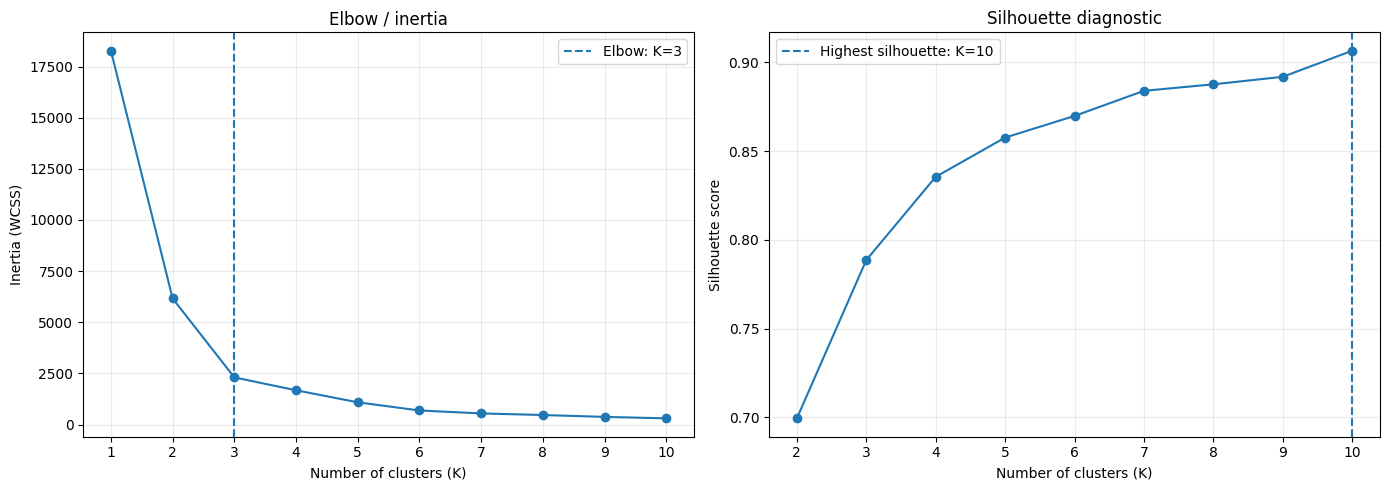

kmeans diagnostics complete. Advisory recommended n=4; choose n manually for the final fit.


,n,k,inertia,silhouette,elbow_strength,silhouette_strength,combined_score
0,1,1,18276.000000,NaN,0.000000,NaN,NaN
1,2,2,6162.247363,0.699414,0.844594,0.000000,0.422297
2,3,3,2303.666757,0.788579,1.000000,0.430505,0.715252
3,4,4,1674.190918,0.835484,0.885823,0.656973,0.771398
4,5,5,1086.343320,0.857587,0.768170,0.763690,0.765930
5,6,6,685.648737,0.869786,0.634892,0.822593,0.728743
6,7,7,543.340745,0.883938,0.480043,0.890921,0.685482
7,8,8,463.668966,0.887602,0.319965,0.908608,0.614287
8,9,9,372.456429,0.891832,0.160851,0.929035,0.544943
9,10,10,302.035841,0.906530,0.000000,1.000000,0.500000


Elbow k: 3
Silhouette k: 10
Combined best k: 4


In [10]:
# Baseline K-means diagnostics on all four post-KG coordinates.
kdiag = model.diagnostics(
    "kmeans", positive_disease=DISEASE, min_clusters=2, max_clusters=10,
    variables=None, show=True, print_recommendations=True
)
display(kdiag)
print("Elbow k:", kdiag.attrs.get("elbow_recommended_n"))
print("Silhouette k:", kdiag.attrs.get("silhouette_recommended_n"))
print("Combined best k:", kdiag.attrs.get("best_k", kdiag.attrs.get("recommended_n")))

## 6. Pre-specified baseline partition and retrospective evaluation

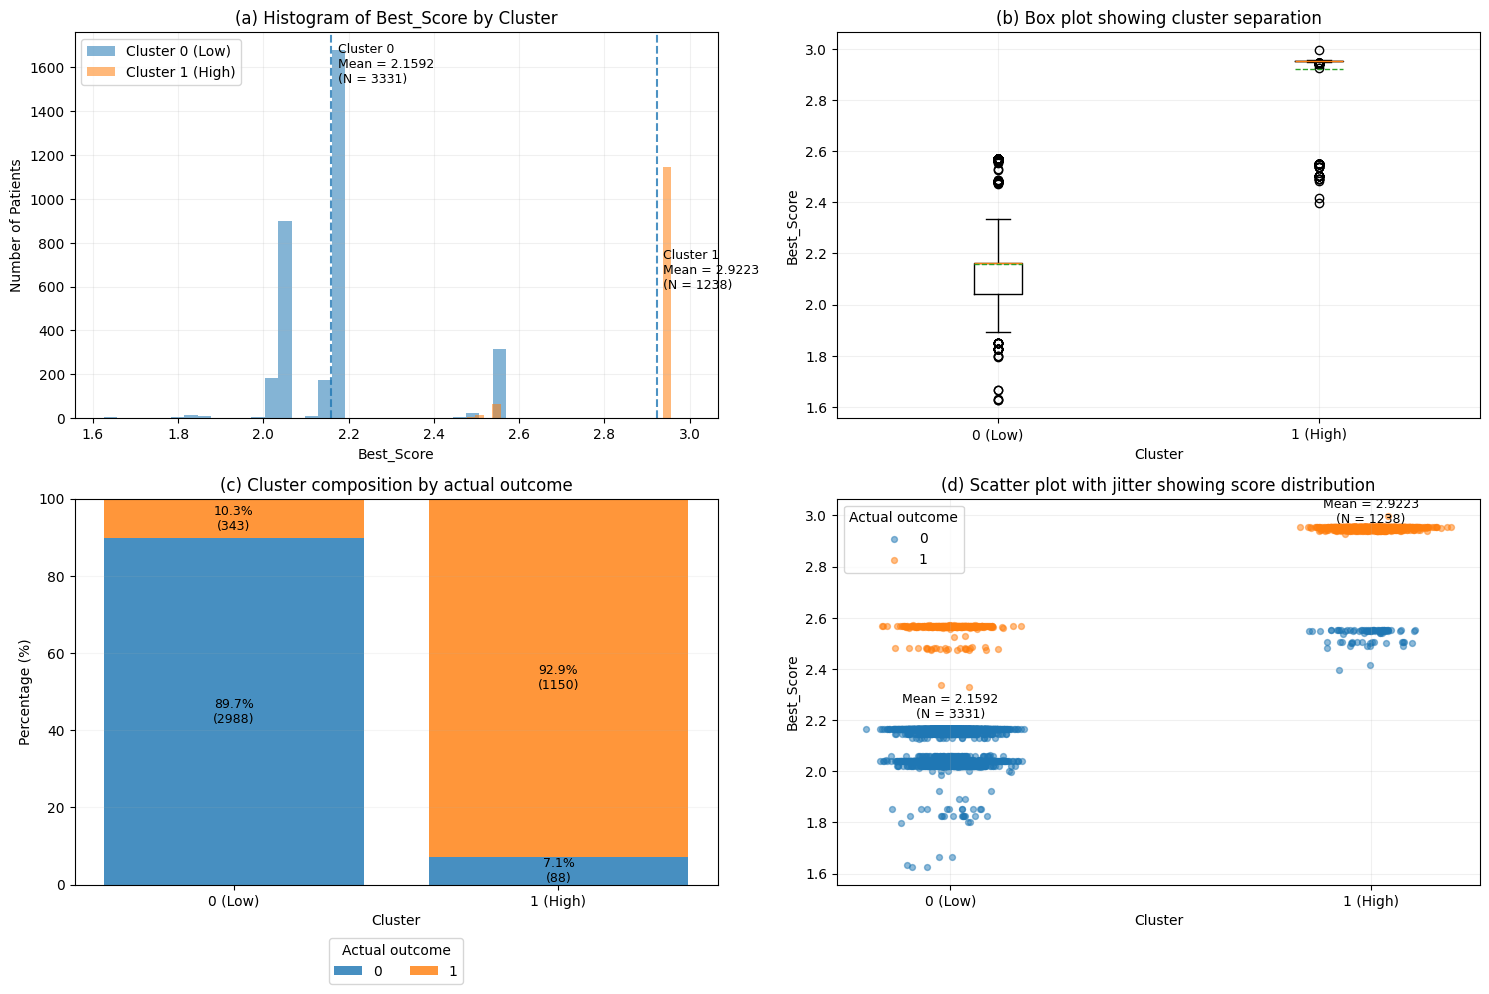

ALL-RECORD EVALUATION
{'n': 4569, 'accuracy': 0.905668636463121, 'balanced_accuracy': np.float64(0.8708263182236653), 'precision_macro': 0.9129727642952652, 'recall_macro': 0.8708263182236653, 'f1_macro': 0.8874560887696237, 'f1_weighted': 0.9031418684207697, 'mcc': np.float64(0.782665112829907), 'cohen_kappa': np.float64(0.7757455612063447), 'ground_truth_counts': {'negative': 3076, 'positive': 1493}, 'prediction_counts': {'negative': 3331, 'positive': 1238}, 'labels': ['negative', 'positive'], 'confusion_matrix': array([[2988,   88],
       [ 343, 1150]]), 'binary_label_order': ['negative', 'positive'], 'tn': 2988, 'fp': 88, 'fn': 343, 'tp': 1150, 'sensitivity': np.float64(0.7702612190221031), 'specificity': np.float64(0.9713914174252276), 'npv': np.float64(0.8970279195436806), 'ppv': np.float64(0.9289176090468497), 'f1_positive': 0.8421823507872574, 'f1': 0.8421823507872574, 'n_total': 4569, 'n_indeterminate': 0, 'coverage': 1.0, 'abstention_rate': 0.0, 'positive_disease': 'Influenz

In [11]:
from ckg_reasoner import KMeansPartition

km = model.partition(
    KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                    random_state=RANDOM_STATE, n_init=20, variables=None),
    DISEASE, show=False
)
km.visualize(y_true=model.df_[TARGET])

result_all = model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
result_selective = model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
print("ALL-RECORD EVALUATION")
print(result_all)
print("\nDECIDED/SUBSET EVALUATION")
print(result_selective)

## 7. Manuscript component ablation — post-KG representation

These experiments change only the coordinates supplied to K-means. They do **not** refit the diagnostic reasoner. The first six rows correspond to the manuscript table; `No CS` is an additional exploratory check.

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score

ABLATIONS = {
    "Full": None,  # variables=None => all four eligible coordinates
    "No P_evidence": ["r", "c", "Confidence_Score"],
    "No r": ["P_evidence", "c", "Confidence_Score"],
    "No c": ["P_evidence", "r", "Confidence_Score"],
    "P_evidence only": ["P_evidence"],
    "Profile only (r,c)": ["r", "c"],
    "No CS [exploratory]": ["P_evidence", "r", "c"],
}

def metric_value(d, *names):
    for n in names:
        if n in d: return d[n]
    return np.nan

baseline_tags = km.predictions_.astype(str)
rows=[]
partition_objects={}
for name, variables in ABLATIONS.items():
    part=model.partition(KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                         random_state=RANDOM_STATE, n_init=20, variables=variables), DISEASE, show=False)
    partition_objects[name]=part
    allm=model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    selm=model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    rows.append({
        "ablation":name, "variables":"ALL 4" if variables is None else ", ".join(variables),
        "ARI_vs_full":adjusted_rand_score(baseline_tags,part.predictions_.astype(str)),
        "accuracy_all":metric_value(allm,"accuracy"),
        "balanced_accuracy_all":metric_value(allm,"balanced_accuracy"),
        "MCC_all":metric_value(allm,"mcc","matthews_corrcoef"),
        "F1_positive_all":metric_value(allm,"f1_positive","f1"),
        "F1_positive_decided":metric_value(selm,"f1_positive","f1"),
        "coverage":metric_value(selm,"coverage"),
        "n_indeterminate":metric_value(selm,"n_indeterminate"),
    })
component_ablation=pd.DataFrame(rows)
display(component_ablation)

,ablation,variables,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,F1_positive_all,F1_positive_decided,coverage,n_indeterminate
0,Full,ALL 4,1.000000,0.905669,0.870826,0.782665,0.842182,0.842182,1.0,0
1,No P_evidence,"r, c, Confidence_Score",1.000000,0.905669,0.870826,0.782665,0.842182,0.842182,1.0,0
2,No r,"P_evidence, c, Confidence_Score",0.997253,0.906325,0.871314,0.784293,0.843109,0.843109,1.0,0
3,No c,"P_evidence, r, Confidence_Score",0.993594,0.907201,0.871964,0.786470,0.844347,0.844347,1.0,0
4,P_evidence only,P_evidence,0.649383,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,0
5,"Profile only (r,c)","r, c",1.000000,0.905669,0.870826,0.782665,0.842182,0.842182,1.0,0
6,No CS [exploratory],"P_evidence, r, c",1.000000,0.905669,0.870826,0.782665,0.842182,0.842182,1.0,0


## 8. K sensitivity and 20-seed stability

In [13]:
# K sensitivity (K=2,...,10) using all four coordinates.
k_rows=[]
for kval in K_RANGE:
    p=model.partition(KMeansPartition(n_clusters=kval,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=model.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    k_rows.append({"k":kval,"accuracy":metric_value(a,"accuracy"),"balanced_accuracy":metric_value(a,"balanced_accuracy"),
                   "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
k_sensitivity=pd.DataFrame(k_rows)
display(k_sensitivity)

# Seed stability against seed-42 baseline.
seed_rows=[]
for seed in SEEDS:
    p=model.partition(KMeansPartition(n_clusters=BASELINE_K,min_clusters=2,max_clusters=10,random_state=seed,n_init=20,variables=None),DISEASE,show=False)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    seed_rows.append({"seed":seed,"ARI_vs_seed42":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
seed_stability=pd.DataFrame(seed_rows)
display(seed_stability)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

,k,accuracy,balanced_accuracy,f1_positive,coverage
0,2,0.905669,0.870826,0.842182,1.000000
1,3,0.502955,0.571737,0.952381,0.528124
2,4,0.501204,0.570436,0.953170,0.525936
3,5,0.467061,0.518537,0.955854,0.487196
4,6,0.225651,0.339246,0.967460,0.240315
5,7,0.225651,0.339246,0.998997,0.226089
6,8,0.225651,0.339246,0.998997,0.226089
7,9,0.225651,0.339246,0.998997,0.226089
8,10,0.225651,0.339246,0.998997,0.226089


,seed,ARI_vs_seed42,f1_positive,coverage
0,0,1.0,0.842182,1.0
1,1,1.0,0.842182,1.0
2,2,1.0,0.842182,1.0
3,3,1.0,0.842182,1.0
4,4,1.0,0.842182,1.0
5,5,1.0,0.842182,1.0
6,6,1.0,0.842182,1.0
7,7,1.0,0.842182,1.0
8,8,1.0,0.842182,1.0
9,9,1.0,0.842182,1.0


## 9. Bootstrap uncertainty (1,000 nonparametric resamples)

This bootstraps the fixed baseline predictions; it does not refit K-means and therefore quantifies sampling uncertainty of the reported retrospective metrics.

In [14]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef

truth=(model.df_[TARGET].astype(str).str.strip().str.lower().isin(["1","1.0","true","yes","positive","pos"])).astype(int).to_numpy()
pred_tag=km.predictions_.astype(str).to_numpy()
rng=np.random.default_rng(RANDOM_STATE)
boot=[]
for b in range(BOOTSTRAP_N):
    ix=rng.integers(0,len(truth),len(truth))
    yt=truth[ix]; pt=pred_tag[ix]
    yp=(pt=="positive").astype(int)
    decided=(pt!="indeterminate")
    row={"accuracy_all":accuracy_score(yt,yp),"coverage":decided.mean()}
    if len(np.unique(yt))>1:
        row["balanced_accuracy_all"]=balanced_accuracy_score(yt,yp)
        row["mcc_all"]=matthews_corrcoef(yt,yp)
    else:
        row["balanced_accuracy_all"]=np.nan; row["mcc_all"]=np.nan
    if decided.any(): row["f1_positive_decided"]=f1_score(yt[decided],yp[decided],zero_division=0)
    else: row["f1_positive_decided"]=np.nan
    boot.append(row)
bootstrap_df=pd.DataFrame(boot)
bootstrap_ci=bootstrap_df.quantile([0.025,0.5,0.975]).T.rename(columns={0.025:"CI_2.5%",0.5:"median",0.975:"CI_97.5%"})
display(bootstrap_ci)

,CI_2.5%,median,CI_97.5%
accuracy_all,0.896914,0.905669,0.914204
coverage,1.000000,1.000000,1.000000
balanced_accuracy_all,0.859505,0.870867,0.881636
mcc_all,0.763670,0.782656,0.800618
f1_positive_decided,0.827500,0.842412,0.856413


## 10. Reasoner-level ablations: contradiction and clinical importance

These rerun `graphfit()` after changing the encoded disease knowledge. They are intentionally separate from coordinate ablation.

In [15]:
from copy import deepcopy

def fresh_model_from_df(df_variant, knowledge_ablation=None):
    m=CKGModel()
    if knowledge_ablation is not None:
        for disease_key, refs in m.kb.reference_vectors.items():
            for _, ref in refs.items():
                if knowledge_ablation=="no_contradiction": ref["contradiction"]="None"
                elif knowledge_ablation=="importance_unity": ref["importance"]="Critical"  # encoded value 1.0
    m.hmap(df_variant.copy(),interactive=False)
    m.graphfit(strategy="exhaustive")
    return m

def run_model_partition(m, k=BASELINE_K):
    p=m.partition(KMeansPartition(n_clusters=k,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=m.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=m.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    return p,a,s

knowledge_rows=[]
for abl in ["no_contradiction","importance_unity"]:
    m2=fresh_model_from_df(df,abl)
    p,a,s=run_model_partition(m2)
    knowledge_rows.append({"ablation":abl,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
        "accuracy_all":metric_value(a,"accuracy"),"f1_positive_decided":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
knowledge_ablation=pd.DataFrame(knowledge_rows)
display(knowledge_ablation)

Detected dataset schema: C4_I1_Thailand_Influenza_4569 (confidence=1.00)
Successful matches found: 14 dataset headings mapped to ontology headings.
                dataset_heading   ontology_heading
RealTimePCRforInfluenzaABAFRIMS PCR_virus_detected
                     Sec3_Fever                FEV
                     Sec3_Cough                COU
                      Sec3_Sore                SOR
                 Sec3_Breathing                DYS
                  Sec3_Headache                HDH
                   Sec3_Malaise                MAL
                     Sec3_Runny                RHI
               Sec3_Generalized                GBA
                     Sec3_Chill                CHL
                  Sec3_Diarrhea                DIA
          Sec3_Injected_pharynx                PHR
         Sec3_Injected_tympanic                TYM
                   Sec4_Ifrapid         AGT_result
Ignored metadata/target headings: ['id', 'CollectionDate', 'Collection_site', 'Gender',

,ablation,ARI_vs_full,accuracy_all,f1_positive_decided,coverage
0,no_contradiction,1.0,0.905669,0.842182,1.0
1,importance_unity,1.0,0.905669,0.842182,1.0


## 11. Evidence-gate parameter sensitivity

One parameter family is varied at a time around the frozen baseline (α=0.05, β=10, γ=0.85). This is a controlled runtime patch for sensitivity analysis only; it does **not** modify the installed package files.

In [16]:
import math, contextlib
import ckg_reasoner.functions as ckg_functions
import ckg_reasoner.reasoning as ckg_reasoning

@contextlib.contextmanager
def temporary_gate(alpha=0.05,beta=10.0,gamma=0.85):
    old_fun=ckg_functions.manuscript_evidence_contributions
    old_reason=ckg_reasoning.manuscript_evidence_contributions
    def contrib(*,information_gate,diagnostic_role,importance,support,contradiction):
        def fgate(x):
            x=float(np.clip(x,0,1)); return 1.0/(1.0+alpha*math.exp(-beta*(x-gamma)))
        ig=float(np.clip(information_gate,0,1))
        return (fgate(ig)*max(float(diagnostic_role),0.0)*float(importance)*max(float(support),0.0),
                fgate(1.0-ig)*abs(float(contradiction)))
    ckg_functions.manuscript_evidence_contributions=contrib
    ckg_reasoning.manuscript_evidence_contributions=contrib
    try: yield
    finally:
        ckg_functions.manuscript_evidence_contributions=old_fun
        ckg_reasoning.manuscript_evidence_contributions=old_reason

gate_settings=[("baseline",0.05,10,0.85)]
gate_settings += [(f"alpha={x}",x,10,0.85) for x in [0.025,0.10]]
gate_settings += [(f"beta={x}",0.05,x,0.85) for x in [5,20]]
gate_settings += [(f"gamma={x}",0.05,10,x) for x in [0.75,0.95]]
gate_rows=[]
for name,a,b,g in gate_settings:
    with temporary_gate(a,b,g):
        mg=fresh_model_from_df(df)
        p,am,sm=run_model_partition(mg)
    gate_rows.append({"setting":name,"alpha":a,"beta":b,"gamma":g,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
gate_sensitivity=pd.DataFrame(gate_rows)
display(gate_sensitivity)

Detected dataset schema: C4_I1_Thailand_Influenza_4569 (confidence=1.00)
Successful matches found: 14 dataset headings mapped to ontology headings.
                dataset_heading   ontology_heading
RealTimePCRforInfluenzaABAFRIMS PCR_virus_detected
                     Sec3_Fever                FEV
                     Sec3_Cough                COU
                      Sec3_Sore                SOR
                 Sec3_Breathing                DYS
                  Sec3_Headache                HDH
                   Sec3_Malaise                MAL
                     Sec3_Runny                RHI
               Sec3_Generalized                GBA
                     Sec3_Chill                CHL
                  Sec3_Diarrhea                DIA
          Sec3_Injected_pharynx                PHR
         Sec3_Injected_tympanic                TYM
                   Sec4_Ifrapid         AGT_result
Ignored metadata/target headings: ['id', 'CollectionDate', 'Collection_site', 'Gender',

,setting,alpha,beta,gamma,ARI_vs_full,f1_positive_decided,coverage
0,baseline,0.050,10,0.85,1.000000,0.842182,1.0
1,alpha=0.025,0.025,10,0.85,1.000000,0.842182,1.0
2,alpha=0.1,0.100,10,0.85,1.000000,0.842182,1.0
3,beta=5,0.050,5,0.85,0.999084,0.842491,1.0
4,beta=20,0.050,20,0.85,1.000000,0.842182,1.0
5,gamma=0.75,0.050,10,0.75,1.000000,0.842182,1.0
6,gamma=0.95,0.050,10,0.95,1.000000,0.842182,1.0


## 12. Controlled random evidence withholding

A fixed random seed masks 10%, 25%, and 50% of observed non-target patient fields and reruns the entire reasoner without refitting ontology weights. Adjust `PROTECTED_COLUMNS` if your local dataset contains additional administrative/non-evidence fields.

In [17]:
PROTECTED_COLUMNS={TARGET,"id","ID","Record_ID","record_id"}
evidence_cols=[c for c in df.columns if c not in PROTECTED_COLUMNS]
withhold_rows=[]
for frac in WITHHOLD_FRACTIONS:
    dfx=df.copy(); rng=np.random.default_rng(RANDOM_STATE+int(frac*100))
    vals=dfx[evidence_cols]
    observed=vals.notna().to_numpy(); draw=rng.random(observed.shape)<frac
    mask=observed & draw
    dfx.loc[:,evidence_cols]=vals.mask(mask)
    mw=fresh_model_from_df(dfx)
    p,am,sm=run_model_partition(mw)
    withhold_rows.append({"withheld_fraction":frac,"actually_masked":int(mask.sum()),"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                          "accuracy_all":metric_value(am,"accuracy"),"balanced_accuracy_all":metric_value(am,"balanced_accuracy"),
                          "MCC_all":metric_value(am,"mcc","matthews_corrcoef"),"f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
evidence_withholding=pd.DataFrame(withhold_rows)
display(evidence_withholding)

/tmp/ipykernel_3887/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.  0.  1. ... 10.  5.  6.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3887/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2010. 2012. 2011. ...   nan 2011.   nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3887/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 9. 11.  3. ...  8.  8.  8.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)


Detected dataset schema: C4_I1_Thailand_Influenza_4569 (confidence=1.00)
Successful matches found: 14 dataset headings mapped to ontology headings.
                dataset_heading   ontology_heading
RealTimePCRforInfluenzaABAFRIMS PCR_virus_detected
                     Sec3_Fever                FEV
                     Sec3_Cough                COU
                      Sec3_Sore                SOR
                 Sec3_Breathing                DYS
                  Sec3_Headache                HDH
                   Sec3_Malaise                MAL
                     Sec3_Runny                RHI
               Sec3_Generalized                GBA
                     Sec3_Chill                CHL
                  Sec3_Diarrhea                DIA
          Sec3_Injected_pharynx                PHR
         Sec3_Injected_tympanic                TYM
                   Sec4_Ifrapid         AGT_result
Ignored metadata/target headings: ['id', 'CollectionDate', 'Collection_site', 'Gender',

/tmp/ipykernel_3887/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.  0. nan ... 10.  5.  6.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3887/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2010. 2012.   nan ...   nan 2011.   nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3887/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 9. 11.  3. ...  8. nan nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)


Detected dataset schema: C4_I1_Thailand_Influenza_4569 (confidence=1.00)
Successful matches found: 14 dataset headings mapped to ontology headings.
                dataset_heading   ontology_heading
RealTimePCRforInfluenzaABAFRIMS PCR_virus_detected
                     Sec3_Fever                FEV
                     Sec3_Cough                COU
                      Sec3_Sore                SOR
                 Sec3_Breathing                DYS
                  Sec3_Headache                HDH
                   Sec3_Malaise                MAL
                     Sec3_Runny                RHI
               Sec3_Generalized                GBA
                     Sec3_Chill                CHL
                  Sec3_Diarrhea                DIA
          Sec3_Injected_pharynx                PHR
         Sec3_Injected_tympanic                TYM
                   Sec4_Ifrapid         AGT_result
Ignored metadata/target headings: ['id', 'CollectionDate', 'Collection_site', 'Gender',

/tmp/ipykernel_3887/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan  0.  1. ... 10.  5. nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3887/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2010.   nan 2011. ...   nan   nan   nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_3887/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 9. 11.  3. ... nan  8.  8.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)


Detected dataset schema: C4_I1_Thailand_Influenza_4569 (confidence=1.00)
Successful matches found: 14 dataset headings mapped to ontology headings.
                dataset_heading   ontology_heading
RealTimePCRforInfluenzaABAFRIMS PCR_virus_detected
                     Sec3_Fever                FEV
                     Sec3_Cough                COU
                      Sec3_Sore                SOR
                 Sec3_Breathing                DYS
                  Sec3_Headache                HDH
                   Sec3_Malaise                MAL
                     Sec3_Runny                RHI
               Sec3_Generalized                GBA
                     Sec3_Chill                CHL
                  Sec3_Diarrhea                DIA
          Sec3_Injected_pharynx                PHR
         Sec3_Injected_tympanic                TYM
                   Sec4_Ifrapid         AGT_result
Ignored metadata/target headings: ['id', 'CollectionDate', 'Collection_site', 'Gender',

,withheld_fraction,actually_masked,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,f1_positive_decided,coverage
0,0.10,10019,0.715831,0.846137,0.832818,0.656203,0.771382,1.0
1,0.25,25349,0.389949,0.765156,0.784394,0.535544,0.700363,1.0
2,0.50,50373,-0.034300,0.372073,0.521583,0.076427,0.497988,1.0


## 13. Influenza confirmatory-evidence ablation — PCR and rapid antigen

The code identifies likely PCR/antigen columns by name and requires confirmation before running. This prevents accidental removal of an unrelated variable.

In [18]:
candidate_pcr=[c for c in df.columns if "pcr" in c.lower()]
candidate_antigen=[c for c in df.columns if ("antigen" in c.lower() or "rapid" in c.lower())]
print("PCR candidates:",candidate_pcr)
print("Rapid/antigen candidates:",candidate_antigen)

# Confirm/edit these if needed before execution.
PCR_COLUMNS=candidate_pcr
ANTIGEN_COLUMNS=candidate_antigen
if not PCR_COLUMNS:
    raise ValueError("No PCR column auto-detected. Set PCR_COLUMNS manually from df.columns.")

confirm_rows=[]
for name,dropcols in [("PCR removed",PCR_COLUMNS),("PCR + rapid antigen removed",PCR_COLUMNS+ANTIGEN_COLUMNS)]:
    dfx=df.copy(); dfx.loc[:,dropcols]=np.nan
    mf=fresh_model_from_df(dfx); p,am,sm=run_model_partition(mf)
    confirm_rows.append({"ablation":name,"removed_columns":", ".join(dropcols),"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                         "accuracy_all":metric_value(am,"accuracy"),"balanced_accuracy_all":metric_value(am,"balanced_accuracy"),
                         "MCC_all":metric_value(am,"mcc","matthews_corrcoef"),"f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
confirmatory_ablation=pd.DataFrame(confirm_rows)
display(confirmatory_ablation)

PCR candidates: ['RealTimePCRforInfluenzaABAFRIMS']
Rapid/antigen candidates: ['Sec4_Ifrapid']
Detected dataset schema: C4_I1_Thailand_Influenza_4569 (confidence=1.00)
Successful matches found: 14 dataset headings mapped to ontology headings.
                dataset_heading   ontology_heading
RealTimePCRforInfluenzaABAFRIMS PCR_virus_detected
                     Sec3_Fever                FEV
                     Sec3_Cough                COU
                      Sec3_Sore                SOR
                 Sec3_Breathing                DYS
                  Sec3_Headache                HDH
                   Sec3_Malaise                MAL
                     Sec3_Runny                RHI
               Sec3_Generalized                GBA
                     Sec3_Chill                CHL
                  Sec3_Diarrhea                DIA
          Sec3_Injected_pharynx                PHR
         Sec3_Injected_tympanic                TYM
                   Sec4_Ifrapid         AGT

,ablation,removed_columns,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,f1_positive_decided,coverage
0,PCR removed,RealTimePCRforInfluenzaABAFRIMS,1.000000,0.905669,0.870826,0.782665,0.842182,1.0
1,PCR + rapid antigen removed,"RealTimePCRforInfluenzaABAFRIMS, Sec4_Ifrapid",-0.037631,0.539068,0.626994,0.262478,0.555321,1.0


## 14. Export manuscript experiment tables

In [19]:
from pathlib import Path
RESULT_DIR=Path("/content/drive/MyDrive/CKG/Results")
RESULT_DIR.mkdir(parents=True,exist_ok=True)
OUT=RESULT_DIR/'D_Influenza_4569'
OUT.mkdir(parents=True,exist_ok=True)
component_ablation.to_csv(OUT/"component_ablation.csv",index=False)
k_sensitivity.to_csv(OUT/"k_sensitivity.csv",index=False)
seed_stability.to_csv(OUT/"seed_stability.csv",index=False)
bootstrap_ci.to_csv(OUT/"bootstrap_95CI.csv")
knowledge_ablation.to_csv(OUT/"knowledge_ablation.csv",index=False)
gate_sensitivity.to_csv(OUT/"gate_sensitivity.csv",index=False)
evidence_withholding.to_csv(OUT/"evidence_withholding.csv",index=False)
confirmatory_ablation.to_csv(OUT/"influenza_confirmatory_ablation.csv",index=False)
print("Saved manuscript experiment tables to:",OUT)

Saved manuscript experiment tables to: /content/drive/MyDrive/CKG/Results/D_Influenza_4569


## 15. Original explainability / FOL / output cells (preserved)

In [20]:
# ------------------------------------------------------------
# 2. Run both FOL outputs for every record
# ------------------------------------------------------------

for idx in range(len(model.df_)):

    model.explain(
        "Influenza",
        row=idx,
        format="fol"
    )

    model.explainable_layer(
        "Influenza",
        row=idx,
        format="report"
    )

print("FOL and explanation layers completed.")

FOL and explanation layers completed.


In [21]:
result_all = model.evaluate(
    y_true="Flu_final_posneg",
    positive_disease="Influenza",
    positive_label=1,
    method=km
)



In [22]:
result_selective = model.evaluate_tag(
    y_true="Flu_final_posneg",
    positive_disease="Influenza",
    positive_label=1,
    method=km
)

In [ ]:
!pip install -q XlsxWriter
output_path = "/content/drive/MyDrive/CKG/Results/CKG_KMeans_outputFOL_Influenza.xlsx"
model.output(
    output_path,
    #"CKG_output.xlsx",
    positive_disease="Influenza",
    method=km
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.7 MB/s eta 0:00:00


In [ ]:
# ============================================================
# K-MEANS EVALUATION
# ============================================================

result_all = model.evaluate(
    y_true="Flu_final_posneg",
    positive_disease="Influenza",
    positive_label=1,
    method=km
)

result_selective = model.evaluate_tag(
    y_true="Flu_final_posneg",
    positive_disease="Influenza",
    positive_label=1,
    method=km
)

print("\n" + "=" * 70)
print("ALL-RECORD EVALUATION")
print("=" * 70)

for metric, value in result_all.items():
    print(f"{metric}: {value}")

print("\n" + "=" * 70)
print("SELECTIVE EVALUATION")
print("=" * 70)

for metric, value in result_selective.items():
    print(f"{metric}: {value}")

In [ ]:
record_id = 3

idx = model.df_.index[model.df_["id"] == record_id][0]

print("Record ID:", record_id)
print("Row:", idx)

# Score / evidence
print("\n=== SCORE ===")
print(model.evidence("Influenza", row=idx))

# FOL
print("\n=== FOL ===")
print(model.explain("Influenza", row=idx, format="fol"))

In [ ]:
record_id = 3
disease = "Influenza"

idx = model.df_.index[model.df_["id"] == record_id][0]

print("Record ID:", record_id, "| Row:", idx)

print("\n=== EVIDENCE / DISEASE SCORE / SIMILARITY ===")
print(model.evidence(disease, row=idx))

print("\n=== CONTINUOUS REASONING ===")
print(model.Continuous_reasoning(disease, row=idx))

print("\n=== DETERMINISTIC REASONING ===")
print(model.Deterministic_reasoning(disease, row=idx))

print("\n=== UNCERTAINTY ===")
print(model.Uncertainty(disease, row=idx))

print("\n=== FOL ===")
print(model.explain(disease, row=idx, format="fol"))

In [ ]:
scores = model.disease_scores()
print(scores)
row_scores = scores.iloc[0].sort_values(ascending=False)
print(row_scores)

for rank, (disease, score) in enumerate(row_scores.items(), start=1):
    print(f"Rank {rank}: {disease} = {score:.6f}")

In [ ]:
# ============================================================
# DISEASE RANK CHECK — ROW 3
# ============================================================

ROW = 4350

print("=" * 70, f"DISEASE RANK DIAGNOSTIC — ROW {ROW}", "=" * 70)

print("\n--- Influenza EVIDENCE ---")

influenza_evidence = model.evidance(
    "Influenza",
    ["specificity", "similarity"],
    row=ROW
)

display(influenza_evidence)


# ------------------------------------------------------------
# 2. influenza continuous reasoning
# ------------------------------------------------------------

print("\n---INFLUENZA CONTINUOUS REASONING ---")

influenza_cont = model.Continuous_reasoning(
    "Influenza",
    row=ROW
)

if influenza_cont is not None:
    display(influenza_cont)


# ------------------------------------------------------------
# 3. influenza deterministic reasoning
# ------------------------------------------------------------

print("\n--- INFLUENZA DETERMINISTIC REASONING ---")

influenza_det = model.Deterministic_reasoning(
    "Influenza",
    row=ROW
)

if influenza_det is not None:
    display(influenza_det)


# ------------------------------------------------------------
# 4. Get scores for all diseases
# ------------------------------------------------------------

print("\n--- ALL DISEASE SCORES ---")

scores = model.disease_scores()

print("Score table shape:", scores.shape)

row_scores = scores.iloc[ROW]

display(
    row_scores.rename("Disease_Score").to_frame()
)


# ------------------------------------------------------------
# 5. Rank diseases
# ------------------------------------------------------------

ranked = row_scores.sort_values(
    ascending=False
)

print("\n--- DISEASE RANKING ---")

for rank, (disease, score) in enumerate(
    ranked.items(),
    start=1
):
    print(
        f"Rank {rank}: "
        f"{disease:<20} "
        f"{float(score):.6f}"
    )


# ------------------------------------------------------------
# 6. Check for zero-score / tied diseases
# ------------------------------------------------------------

print("\n--- SCORE DIAGNOSTICS ---")

zero_scores = row_scores[
    row_scores.abs() < 1e-12
]

if len(zero_scores):
    print(
        "Diseases with effectively zero score:",
        list(zero_scores.index)
    )
else:
    print("No disease has an exact zero score.")

if row_scores.nunique() < len(row_scores):
    print("WARNING: tied disease scores detected.")
else:
    print("No exact score ties detected.")

